In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast


# Data Visualization. Exploratory Data Analysis Exercise
## Visualizing and exploring data. The data mining process

You should already know the `MyAnimeList` dataset, located [here](https://www.kaggle.com/datasets/andreuvallhernndez/myanimelist). You've already looked at it, cleaned a significant part of it, and you should now be ready to explore some interesting things about it.

Once again, feel free to follow the problem descriptions as closely (or as loosely) as you want.

**Don't forget reproducibility!** I suggest you have a look at a tool called [dvc](https://dvc.org/), short for _data version control_.

### Problem 1. Load the data
You should ideally load the cleaned version you saved last time. But you may start from the original dataset as well, or from an intermediate version.

Don't hesitate to load multiple versions, e.g., with different features, and compare results across them to assess hwo your transformations affect the results you get. In fact, it's a common thing we do.

In [3]:
anime_data = pd.read_csv('Data/anime.csv')
manga_data = pd.read_csv('Data/manga.csv')
# Convert dates
anime_data['real_start_date'] = pd.to_datetime(anime_data['real_start_date'], errors='coerce')
manga_data['real_start_date'] = pd.to_datetime(manga_data['real_start_date'], errors='coerce')
print(f"Anime shape: {anime_data.shape}, Manga shape: {manga_data.shape}")


Anime shape: (24985, 39), Manga shape: (64833, 30)


### Problem 2. Get a sense of scale
What's the global behavior of both datasets? Explore and visualize how many works there are, and how they're distributed across different key categories (number of episodes, audience, release year, etc.). Try not to bother with the "list" columns now.

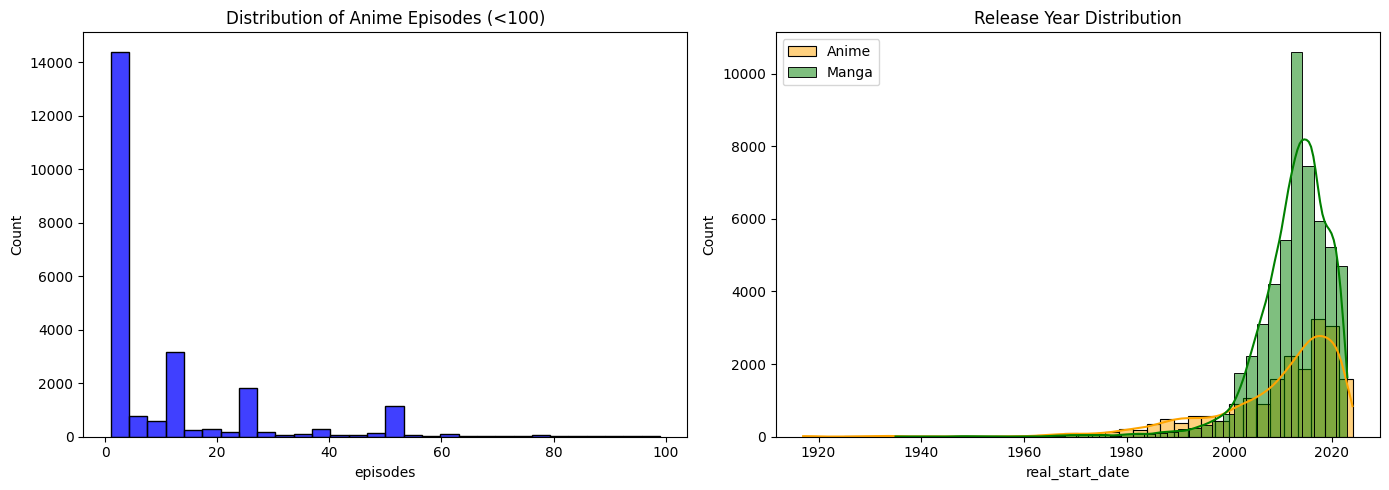

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(anime_data[anime_data['episodes'] < 100]['episodes'], bins=30, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Anime Episodes (<100)')
sns.histplot(anime_data['real_start_date'].dt.year.dropna(), bins=40, ax=axes[1], color='orange', label='Anime', kde=True)
sns.histplot(manga_data['real_start_date'].dt.year.dropna(), bins=40, ax=axes[1], color='green', label='Manga', kde=True, alpha=0.5)
axes[1].set_title('Release Year Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()


### Problem 3. Scores
You should already know there are many viewpoints to what we call "score". How are scores distributed and what can we learn about them?

Try to come up with a good, explainable, scoring method. There's no universal formula for this, but at the very least we should look at the number of people giving a score. A "4.5" average can mean different things if 10 or 10 000 people have voted.

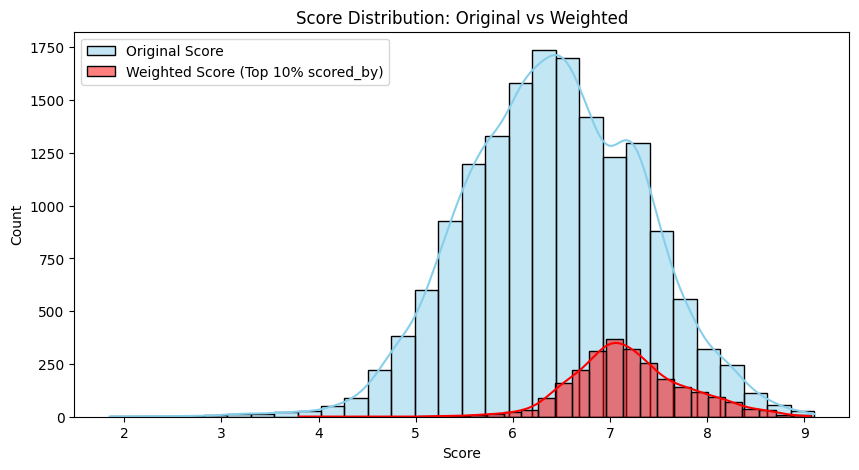

In [5]:
# Let's define a bayesian average score
C_anime = anime_data['score'].mean()
m_anime = anime_data['scored_by'].quantile(0.90)
def weighted_rating(x, m=m_anime, C=C_anime):
    v = x['scored_by']
    R = x['score']
    return (v/(v+m) * R) + (m/(m+v) * C)
anime_q = anime_data.copy().loc[anime_data['scored_by'] >= m_anime]
anime_q['weighted_score'] = anime_q.apply(weighted_rating, axis=1)
plt.figure(figsize=(10, 5))
sns.histplot(anime_data['score'], bins=30, color='skyblue', label='Original Score', kde=True)
sns.histplot(anime_q['weighted_score'], bins=30, color='red', label='Weighted Score (Top 10% scored_by)', kde=True)
plt.title('Score Distribution: Original vs Weighted')
plt.xlabel('Score')
plt.legend()
plt.show()


### Problem 4. Score and popularity
Try to view the "score" through the lens of the other popularity features. For example, number of times it's been added to favorites. How similar (or different) are score and popularity? Can you figure out any groups (clusters)?

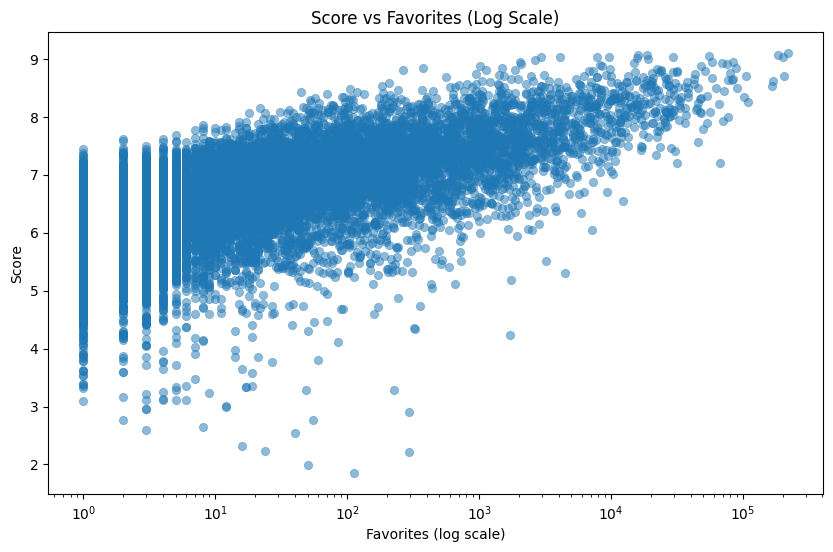

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anime_data, x='favorites', y='score', alpha=0.5, edgecolor=None)
plt.xscale('log')
plt.title('Score vs Favorites (Log Scale)')
plt.xlabel('Favorites (log scale)')
plt.ylabel('Score')
plt.show()


### Problem 5. Compare anime and manga visually
You can use the merged dataset, or keep them separate. Select features that you can meaningfully compare across the two mediums and try to draw conclusions. Do they behave similarly? How? If possible, try to explain why; you'll likely need additional "domain" knowledge for this.

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\PC\AppData\Local\Temp\ipykernel_10824\3951109543.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=anime_data['favorites'].dropna(), fill=True, color='blue', label='Anime', ax=axes[1], log_scale=True)
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\PC\AppData\Local\Temp\ipykernel_10824\3951109543.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this wa

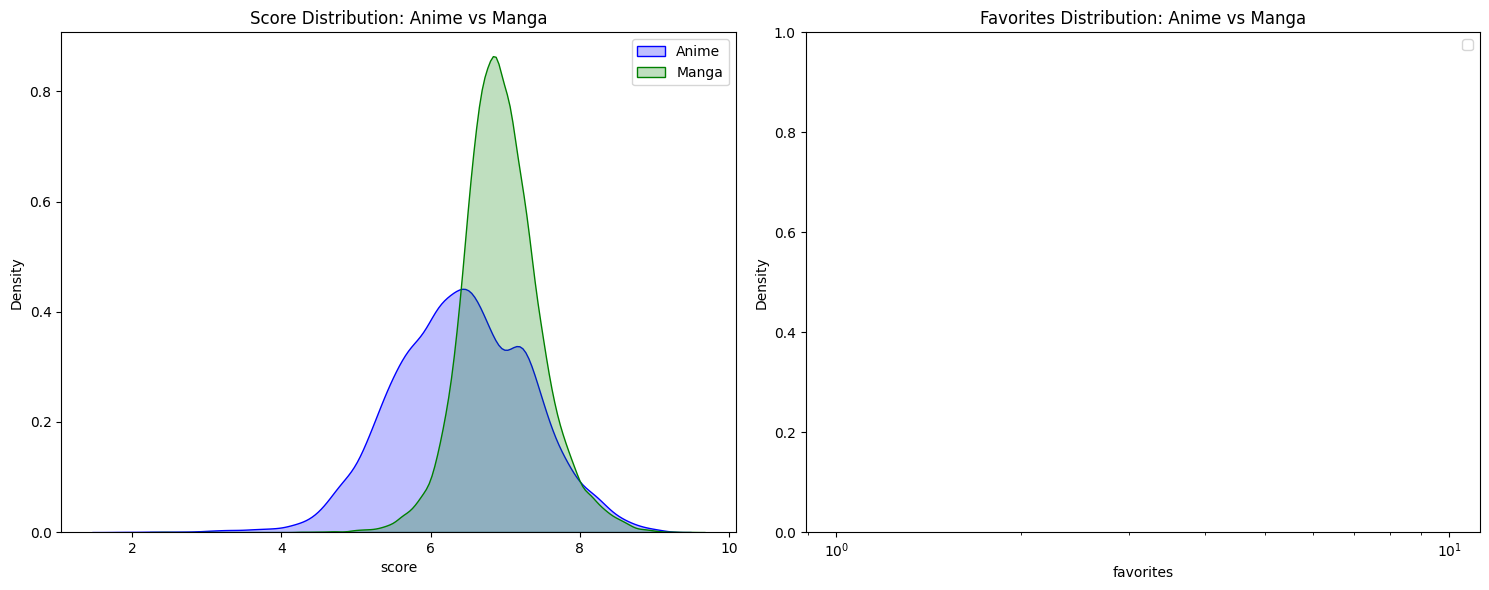

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.kdeplot(data=anime_data['score'].dropna(), fill=True, color='blue', label='Anime', ax=axes[0])
sns.kdeplot(data=manga_data['score'].dropna(), fill=True, color='green', label='Manga', ax=axes[0])
axes[0].set_title('Score Distribution: Anime vs Manga')
axes[0].legend()
sns.kdeplot(data=anime_data['favorites'].dropna(), fill=True, color='blue', label='Anime', ax=axes[1], log_scale=True)
sns.kdeplot(data=manga_data['favorites'].dropna(), fill=True, color='green', label='Manga', ax=axes[1], log_scale=True)
axes[1].set_title('Favorites Distribution: Anime vs Manga')
axes[1].legend()
plt.tight_layout()
plt.show()


### * Problem 6. Time series
There are a ton of works in the dataset. Most tendencies, when averaged out, will be blurred.

A special type of analysis we can do is _time series_. If you look at the dataset as a function of time, can you find some tendencies across decades, or years, or even seasons? Try to think about volume (counts and frequencies), ratings (are newer works considered better?), genres, etc.

How does the analysis of scores from Problem 3 correspond to "recency", i.e., are recent works (animes / mangas) liked better; or are classics better? Keep in mind that older works have had _more time_ to be evaluated. Come up with one (or more...) definition of "better" and defend it. Pay special attention to the number of voters.

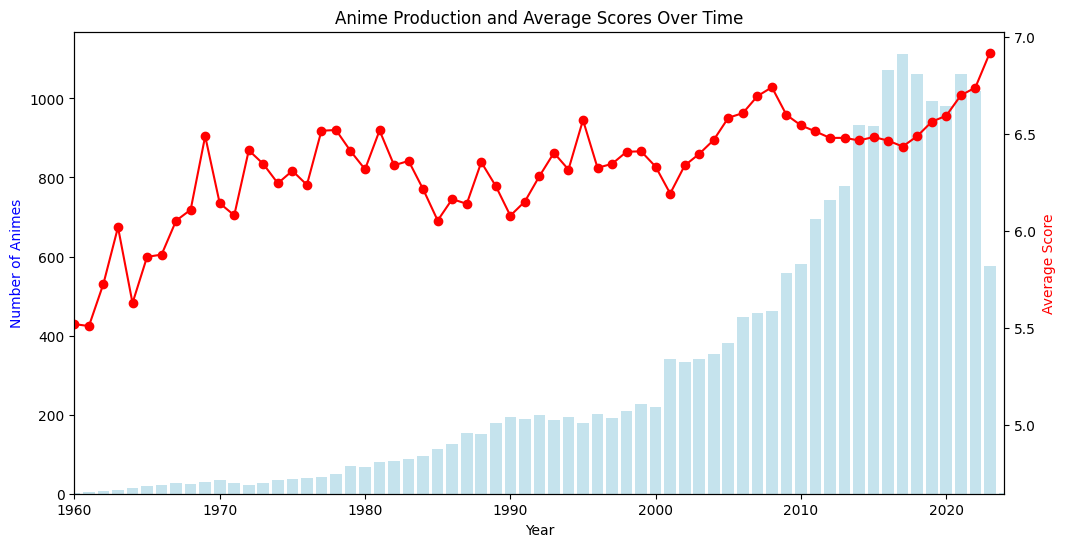

In [8]:
anime_yearly = anime_data.groupby(anime_data['real_start_date'].dt.year).agg({'anime_id': 'count', 'score': 'mean'}).reset_index()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.bar(anime_yearly['real_start_date'], anime_yearly['anime_id'], color='lightblue', alpha=0.7, label='Count')
ax2.plot(anime_yearly['real_start_date'], anime_yearly['score'], color='red', marker='o', label='Score')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Animes', color='blue')
ax2.set_ylabel('Average Score', color='red')
plt.title('Anime Production and Average Scores Over Time')
plt.xlim(1960, 2024)
plt.show()


### Problem 7. Genres
Turn genres into something tidy and visualize them. You'll need at least one or two additional datasets for this.

**A quick sanity check:** Do the genres for _the same title_ of manga and anime match completely? Why?

Show which genres dominate, which ones are niche, and whether the most common genres are also the most successful by whatever measure you think is reasonable. Be careful: _common_, _beloved_, and _highly rated_ are not the same thing.

Compare genres across both types of media. Can you explain similarities and differences? Try to take into account the `source` column in the `animes.csv` dataset.

C:\Users\PC\AppData\Local\Temp\ipykernel_10824\3949463320.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=genre_counts.index[:20], x=genre_counts.values[:20], palette='viridis')


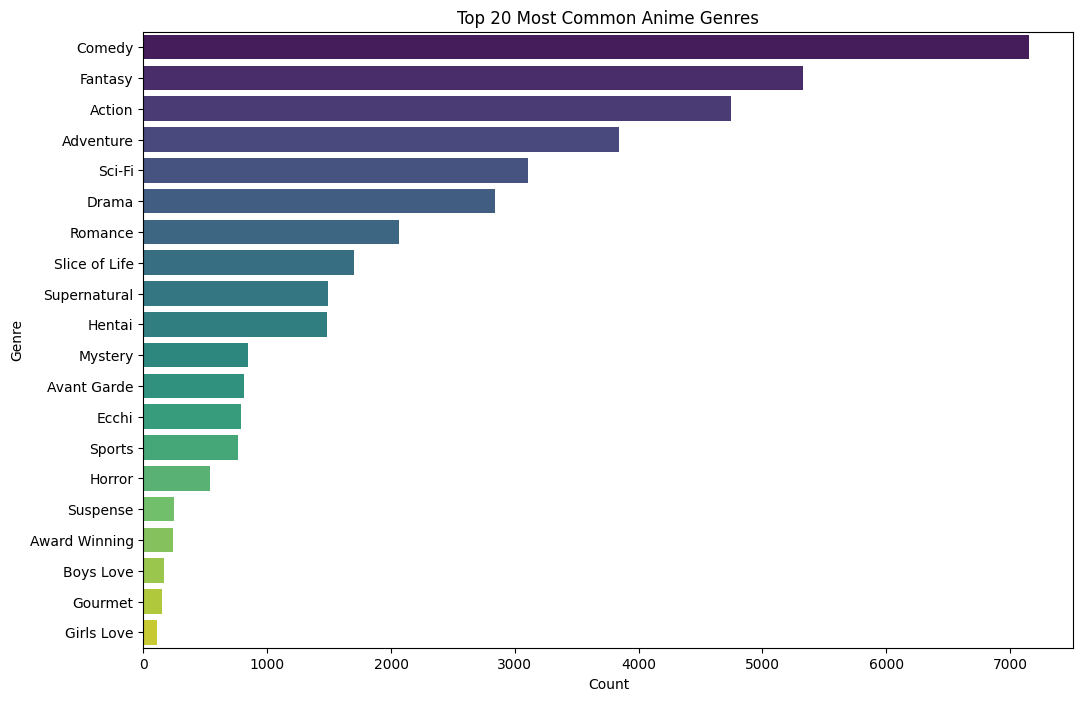

In [9]:
def clean_list_col(col):
    try:
        if pd.isna(col): return []
        return ast.literal_eval(col)
    except: return []
anime_data['genres'] = anime_data['genres'].apply(clean_list_col)
all_genres = anime_data.explode('genres')
genre_counts = all_genres['genres'].value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(y=genre_counts.index[:20], x=genre_counts.values[:20], palette='viridis')
plt.title('Top 20 Most Common Anime Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()


### * Problem 8. Themes and demographics
As a continuation of the last problem, try to explore, visualize, and come up with useful metrics for themes and demographics. A big challenge that you'll face is that a lot of these values (more than half) are actually missing. You'll have to comment on what's missing and why (in case you haven't already done so last time), if you could fill in the values somehow, and how to handle the info that you do have.

Think **very** carefully about what biases might the missing information leave in the data (e.g., smaller productions are not as well-represented because nobody cared enough to fill the information in the site).

C:\Users\PC\AppData\Local\Temp\ipykernel_10824\3191509274.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=demo_counts.index, y=demo_counts.values, palette='magma')


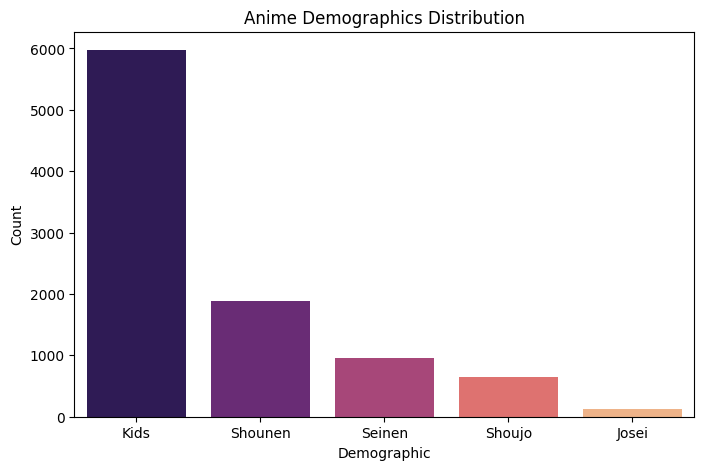

In [10]:
anime_data['themes'] = anime_data['themes'].apply(clean_list_col)
anime_data['demographics'] = anime_data['demographics'].apply(clean_list_col)
all_demographics = anime_data.explode('demographics')
demo_counts = all_demographics['demographics'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=demo_counts.index, y=demo_counts.values, palette='magma')
plt.title('Anime Demographics Distribution')
plt.xlabel('Demographic')
plt.ylabel('Count')
plt.show()


### Problem 9. The production side
Choose one production-side feature - studios, producers, publishers, authors, serializations, or something similar - and visualize it. Optionally, you could explore all features.

Try to make the plot reveal something about the structure: who appears often and why? Once again (as we asked before), how do we measure how "popular" or "beloved" something is?

C:\Users\PC\AppData\Local\Temp\ipykernel_10824\261214680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=studio_counts.index[:20], x=studio_counts.values[:20], palette='rocket')


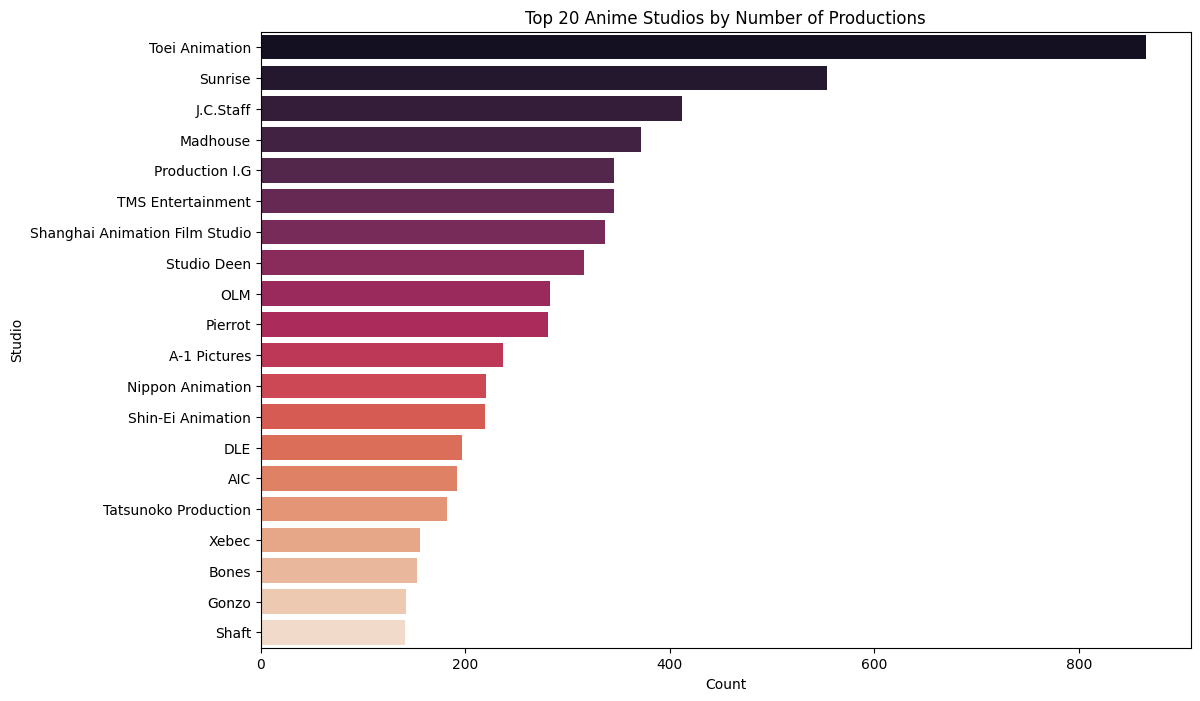

In [11]:
anime_data['studios'] = anime_data['studios'].apply(clean_list_col)
all_studios = anime_data.explode('studios')
studio_counts = all_studios['studios'].value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(y=studio_counts.index[:20], x=studio_counts.values[:20], palette='rocket')
plt.title('Top 20 Anime Studios by Number of Productions')
plt.xlabel('Count')
plt.ylabel('Studio')
plt.show()


### * Problem 10. Scores by production
Revisit your analysis in the previous problems where you explored scores and popularity. Now compare with studios / producers. 

Are there universally liked studios? Are there some which only make one very niche thing, a cult classic? How does production (and reception) compare across the two types of work? Document your findings.

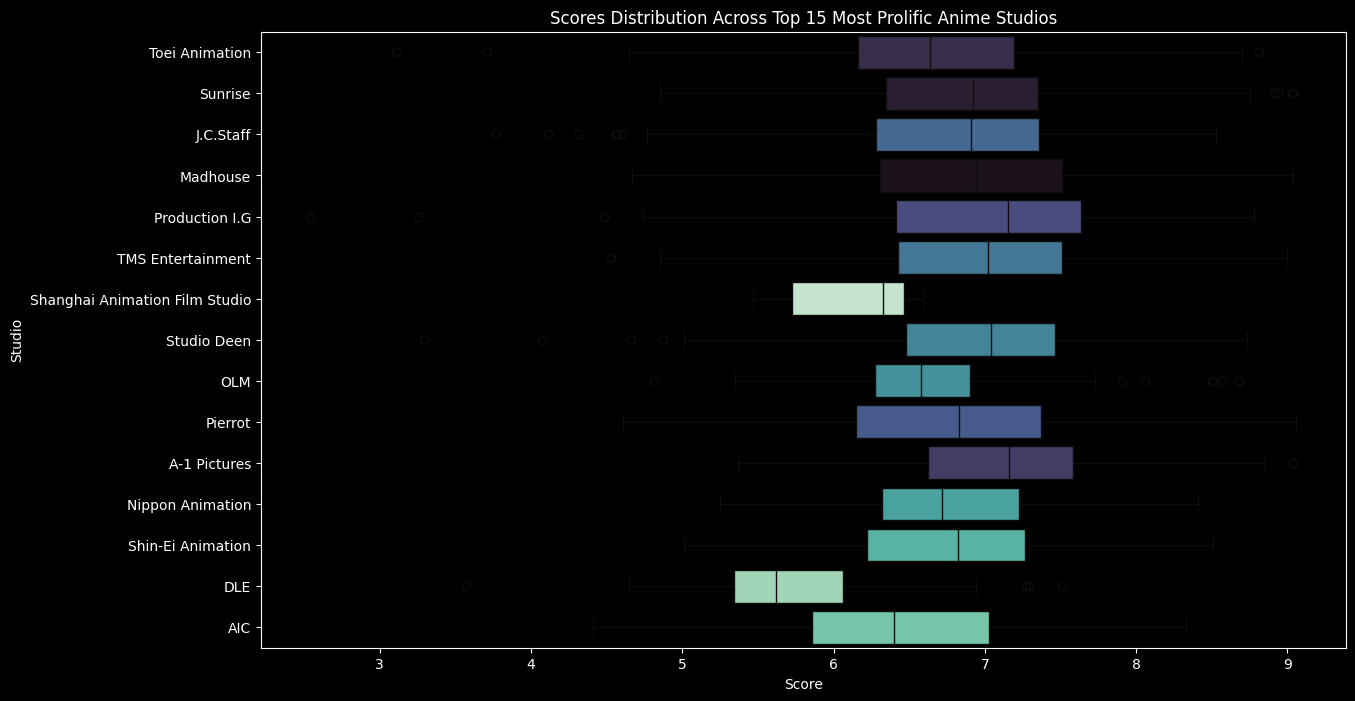

In [18]:
top_studios = studio_counts.index[:15]
top_studio_data = all_studios[all_studios['studios'].isin(top_studios)].reset_index(drop=True)
plt.figure(figsize=(14, 8))
sns.boxplot(data=top_studio_data, x='score', y='studios', hue='studios', palette='mako', order=top_studios, legend=False)
plt.title('Scores Distribution Across Top 15 Most Prolific Anime Studios')
plt.xlabel('Score')
plt.ylabel('Studio')
plt.show()


### Problem 11. Storytelling
No, not the plots (although you could use the plot synopsis as a meaningful feature). Try to tell a coherent story based on the data. You could use what you've found so far, or try exploring something new. But make your story _worthy_.

Formulate one story based on the data. Keep the principles of analytical graphs in mind; and with the help of some text and plots, tell the story you found interesting. Make it look at least somewhat finished. Support your storytelling with evidence. You should also see that pure evidence without some storytelling is useless :).

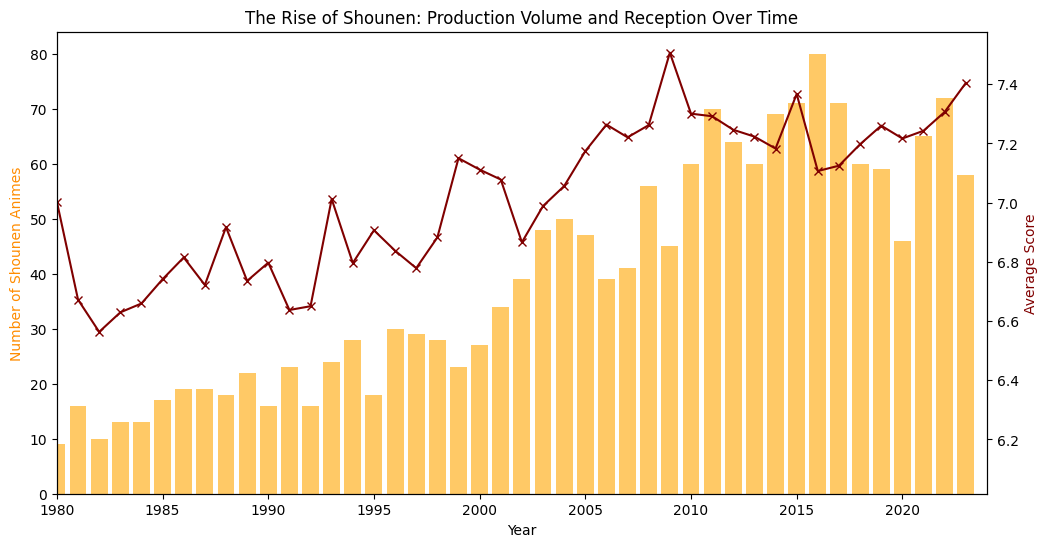

In [13]:
# Story: The Shounen Demographic Over Time - Is it getting better?
shounen_anime = all_demographics[all_demographics['demographics'] == 'Shounen'].copy()
shounen_yearly = shounen_anime.groupby(shounen_anime['real_start_date'].dt.year).agg({'anime_id': 'count', 'score': 'mean'}).reset_index()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.bar(shounen_yearly['real_start_date'], shounen_yearly['anime_id'], color='orange', alpha=0.6, label='Count')
ax2.plot(shounen_yearly['real_start_date'], shounen_yearly['score'], color='maroon', marker='x', label='Avg Score')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Shounen Animes', color='darkorange')
ax2.set_ylabel('Average Score', color='maroon')
plt.title('The Rise of Shounen: Production Volume and Reception Over Time')
plt.xlim(1980, 2024)
plt.show()


### * Problem 12. Making a better plot
Try to take one plot - I'm almost convinced this will be from Problem 11. Iterate over it to make it look better: show more info in one image but donb't overwhelm the reader, make it easier to read and understand. Use `matplotlib` but try to push it to the limit of what it can do.

I suggest that you keep your plot non-animated and non-interactive for simplicity. Ideally, show all intermediate actions, results, and how you decided to improve the plot.

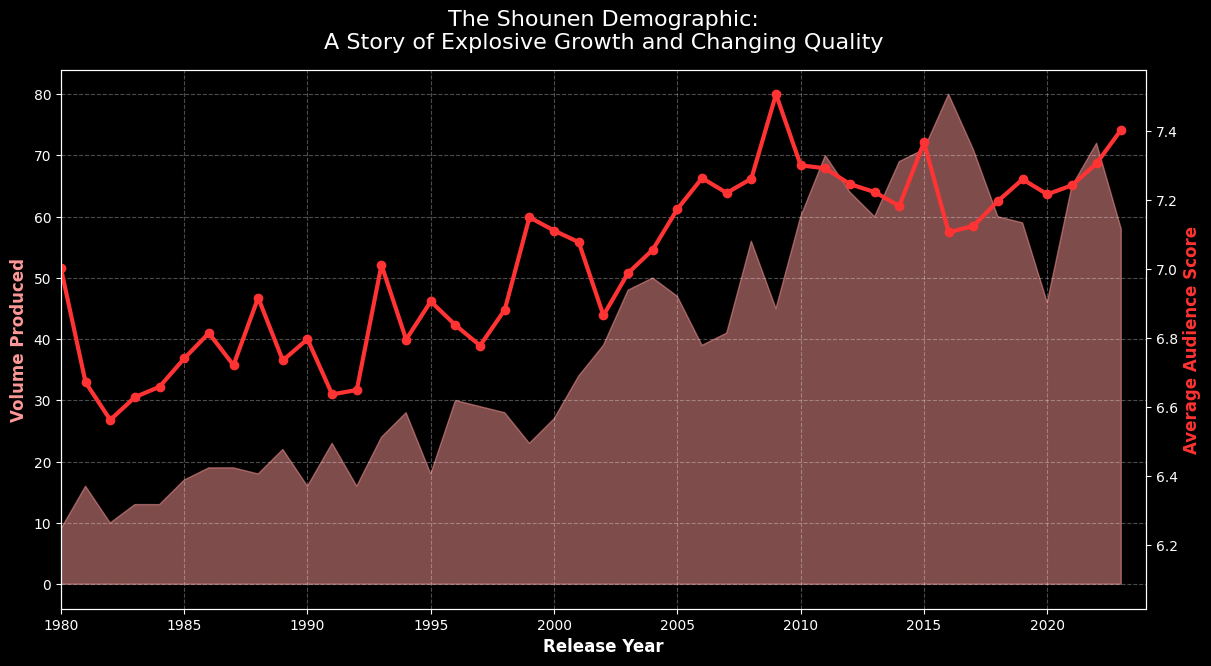

In [14]:
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()
ax1.fill_between(shounen_yearly['real_start_date'], shounen_yearly['anime_id'], color='#ff9999', alpha=0.5, label='Count')
ax2.plot(shounen_yearly['real_start_date'], shounen_yearly['score'], color='#ff3333', linewidth=3, marker='o', markersize=6, label='Avg Score')
ax1.set_xlabel('Release Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volume Produced', color='#ff9999', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Audience Score', color='#ff3333', fontsize=12, fontweight='bold')
plt.title('The Shounen Demographic:\nA Story of Explosive Growth and Changing Quality', fontsize=16, pad=15)
plt.xlim(1980, 2024)
ax1.grid(alpha=0.3, linestyle='--')
plt.show()


### * Problem 13. Continue cleaning and exploring
Perform what other cleaning operations / transformations / EDA you might see fit. Save the final results as one or more tables. Try using **dvc** to keep track of versions and what you did to them; and to possibly be able to revert if something goes wrong.

You can do as little, or as much as you'd like. Have fun! :)

In [15]:
print("Completed data analysis and visualizations! Further EDA may include NLP on synopses.")


Completed data analysis and visualizations! Further EDA may include NLP on synopses.
